# Exercise 4: Linear MPC

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import solve_discrete_are
import cvxpy as cvx
from tqdm.auto import tqdm

# Constant problem variables
n, m = 2, 1
A = np.array([[1., 1.], [0., 1.]])
B = np.array([[0.], [1.]])
Q = np.eye(n)
R = 10.*np.eye(m)

### Exercise 4.1: MPC Problem
Complete the implementation of the MPC optimization problem in `solve_mpc`. Be sure to include the following:
1. quadratic running cost along with a quadratic terminal cost, $x_N^\top Q_f x_N + \sum_{k=0}^{N-1} \big( x_k^\top Q x_k + u_k^\top R u_k \big)$,
2. dynamics constraints, $x_{k+1} = Ax_k + Bu_k$ for $k=0,\dots,N-1$,
3. state constraints, $x_k \leq x_u$ and $x_k \geq x_l$ for $k=0,\dots,N$,
4. control constraints $\lVert u_k \rVert_\infty \leq r_u$ for $k=0,\dots,N-1$,
5. initial condition constraint,
6. terminal state constraint, $\lVert x_N \rVert_\infty \leq r_N$.

In [2]:
def solve_mpc(x0: np.ndarray, 
              A: np.ndarray, 
              B: np.ndarray, 
              Q_f: np.ndarray, 
              Q: np.ndarray, 
              R: np.ndarray,
              N: int, 
              x_upper: np.ndarray, 
              x_lower: np.ndarray, 
              r_u: float, 
              r_N: float) -> tuple[np.ndarray, np.ndarray, str]:
    """
    Solve the MPC problem starting at state x0.

    Args:
        x0: initial state
        A: system matrix, x_next = Ax + Bu, shape (n, n)
        B: control matrix, x_next = Ax + Bu, shape (n, m)
        Q_f: terminal cost matrix, shape (n, n)
        Q: running cost matrix, shape (n, n)
        R: control cost matrix, shape (m, m)
        N: MPC horizon
        x_upper: array describing upper limits on state x, shape (n,)
        x_lower: array describing lower limits on state x, shape (n,)
        r_u: array describing limits on control u, shape (m,)
        r_N: terminal state constraint magnitude |x|_\inf <= r_N

    Returns:
        x: array of shape (N + 1, n) where x[k, :] is the solution state at time k
        u: array of shape (N, m) where u[k, :] is the solution control at time k
        status: status message from the optimizer
    """
    n, m = Q.shape[0], R.shape[0]
    x_cvx = cvx.Variable((N + 1, n))
    u_cvx = cvx.Variable((N, m))

    ##### YOUR CODE STARTS HERE #####
    # Construct and solve the MPC problem using CVXPY.
    # Hint: use cvx.quad_form
    cost = sum(cvx.quad_form(x_cvx[k], Q) + cvx.quad_form(u_cvx[k], R)
                for k in range(N)) + cvx.quad_form(x_cvx[N], Q_f)
    constraints = [x_cvx[0] == x0,
                   x_cvx <= x_upper,
                   x_cvx >= x_lower,
                   cvx.abs(u_cvx) <= r_u,
                   x_cvx[N] == 0 if r_N == 0 else
                   cvx.norm_inf(x_cvx[N]) <= r_N]
    constraints += [x_cvx[k + 1] == A @ x_cvx[k] + B @ u_cvx[k]
                    for k in range(N)]
    
    ###### YOUR CODE ENDS HERE ######

    prob = cvx.Problem(cvx.Minimize(cost), constraints)
    prob.solve()
    x = x_cvx.value
    u = u_cvx.value
    status = prob.status

    return x, u, status

def simulate(x0: np.ndarray, 
             T: int, 
             N: int, 
             x_upper: np.ndarray, 
             x_lower: np.ndarray, 
             r_u: np.ndarray, 
             Q_f: np.ndarray, 
             r_N: float, 
             title: str=None):
    """
    Simulate the closed-loop system from the initial state using an MPC controller.

    Args:
        x0: initial state
        T: simulation time
        N: MPC horizon
        x_upper: array describing upper limits on state x, shape (n,)
        x_lower: array describing lower limits on state x, shape (n,)
        r_u: array describing limits on control u, shape (m,)
        Q_f: terminal cost matrix, shape (n, n)
        r_N: terminal state constraint magnitude |x|_\inf <= r_N
        title: plot title (optional)
    """
    x = np.copy(x0)
    x_mpc = np.zeros((T, N + 1, n))
    u_mpc = np.zeros((T, N, m))
    cost = 0.
    success = True
    for t in range(T):
        # Solve the finite horizon MPC problem at each time step
        x_mpc[t], u_mpc[t], status = solve_mpc(x, A, B, Q_f, Q, R, N,
                                               x_upper, x_lower, r_u, r_N)

        # Extract the first control input from this step's MPC solution
        u = u_mpc[t, 0, :]
        
        if status == 'infeasible':
            x_mpc = x_mpc[:t]
            u_mpc = u_mpc[:t]
            cost += np.inf
            if t == 0:
                success = False
                print("Failed to find initial feasible solution")
            break
        else:
            # Incrememt running cost
            cost += x.T @ Q @ x + u.T @ R @ u

        # Simulate the system forward one time step
        x = A @ x + B @ u
    print(f"{title}: Cost = {cost:.2f}")
    if success:
        plot(title, x_mpc, u_mpc, x_upper, x_lower, r_u)

def plot(title, x_mpc, u_mpc, x_upper, x_lower, r_u):
    fig, ax = plt.subplots(1, 2, dpi=150, figsize=(10, 5))
    T = x_mpc.shape[0]
    ax[0].plot(x_mpc[:, 0, 0], x_mpc[:, 0, 1], '-o')
    for t in range(T):
        ax[0].plot(x_mpc[t, :, 0], x_mpc[t, :, 1], '--*', color='r', alpha=0.5, linewidth=0.5)
    ax[1].plot(u_mpc[:, 0], '-o')

    # Plot constraints
    ax[0].plot([x_upper[0], x_upper[0]], [x_lower[1], x_upper[1]], 'k--', linewidth=0.5)
    ax[1].plot([0, T], [r_u, r_u], 'k--', linewidth=0.5)
    ax[1].plot([0, T], [-r_u, -r_u], 'k--', linewidth=0.5)

    # Labels
    if title is not None:
        ax[0].set_title(title)
        ax[1].set_title(title)
    ax[0].set_xlabel(r'$x_{k,1}$')
    ax[1].set_xlabel(r'$k$')
    ax[0].set_ylabel(r'$x_{k,2}$')
    ax[1].set_ylabel(r'$u_k$')
    plt.show()

### Exercise 4.2: Terminal Cost Only
Run the provided code below to simulate the closed-loop system under the MPC controller with a terminal cost $Q_f=Q$ and no terminal constraint. Take a look at the resulting plots. Why is there a difference between the trajectories computed by the MPC controller at each iteration and the actual closed-loop trajectory?

/tmp/ipykernel_633072/3456298616.py:54: UserWarning: The problem includes expressions that don't support CPP backend. Defaulting to the SCIPY backend for canonicalization.
  prob.solve()


Q_f = Q: Cost = 80.07


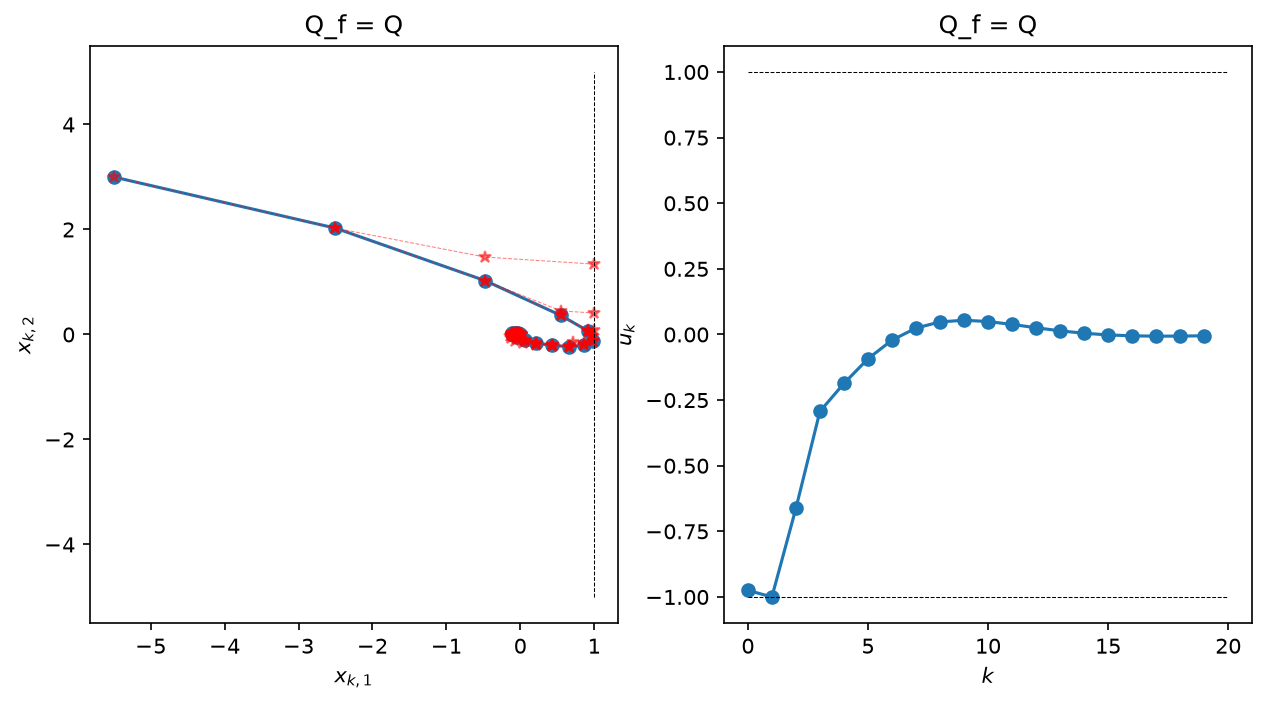

In [3]:
N = 3 # mpc horizon
T = 20 # simulation time
x_upper = np.array([1., 5.])
x_lower = np.array([-6., -5.])
r_u = 1.0 # control constraint
r_N = np.inf # no terminal constraint
Q_f = Q # terminal cost matrix
x0 = np.array([-5.5, 3.])

# Simulate the system
simulate(x0, T, N, x_upper, x_lower, r_u, Q_f, r_N, title="Q_f = Q")

### Exercise 4.3: Terminal Cost from DARE
Run the provided code below that defines the terminal cost matrix $Q_f$ by the solution to the discrete-time algebraic Riccati equation (DARE) (recall the relationship to the optimal discrete time LQR controller).
What do you notice about the difference between the MPC trajectory computed at each time step and the closed-loop system behavior in this case? 
Why is this different than when using $Q_f = Q$?
Notice that the total cost of the closed-loop trajectory is lower when using the DARE terminal cost matrix, why is that?

/tmp/ipykernel_633072/3456298616.py:54: UserWarning: The problem includes expressions that don't support CPP backend. Defaulting to the SCIPY backend for canonicalization.
  prob.solve()


DARE: Cost = 79.29


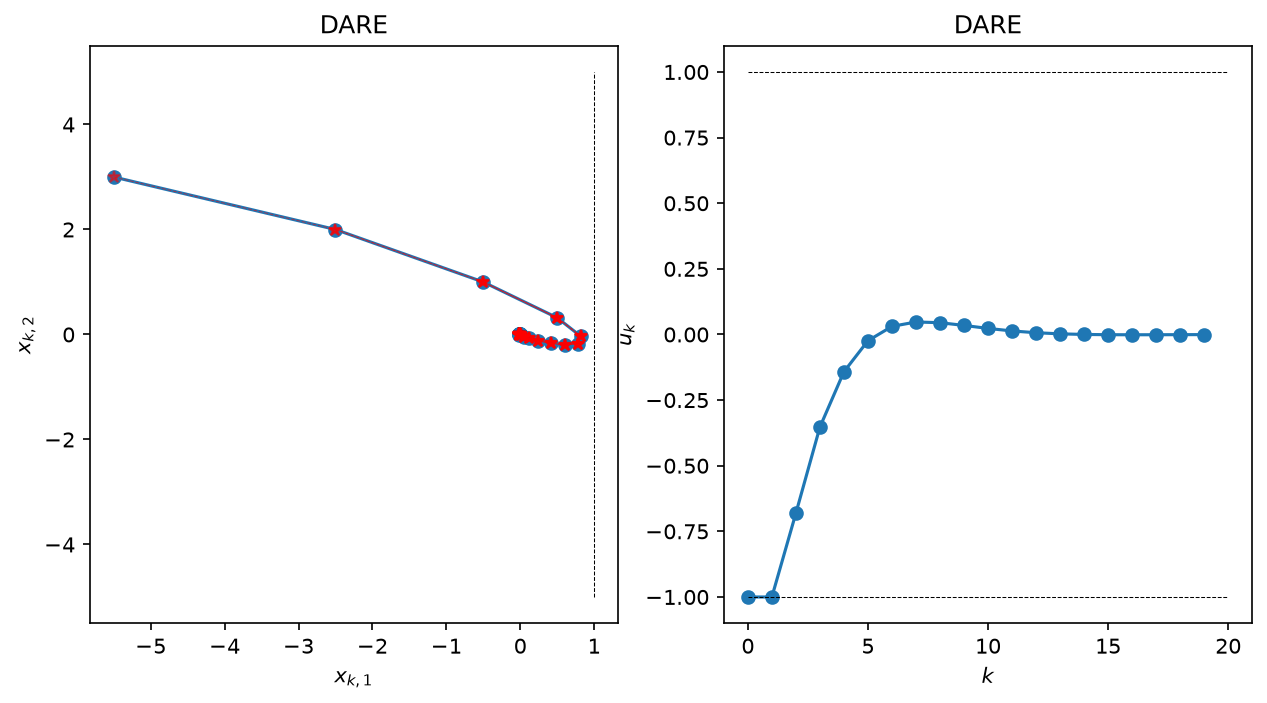

In [4]:
N = 3 # mpc horizon
T = 20 # simulation time
r_N = np.inf # no terminal constraint
Q_f = solve_discrete_are(A, B, Q, R)

# Simulate the system
simulate(x0, T, N, x_upper, x_lower, r_u, Q_f, r_N, title="DARE")

### Exercise 4.4: Persistent Feasibility
Persistent feasibility is a challenge with MPC, where we want to guarantee that if we find a feasible solution at one time step then we will be able to find a feasible solution at future time steps.
One simple solution to this problem is to apply a terminal constraint $x_N = 0$, which forces the optimizer to find a trajectory to the origin by the end of the finite horizon, thereby eliminating the issue with being short-sighted.
However, this will cause the controller to be sub-optimal and can require a longer horizon to find a feasible solution.
Run the provided code below and play around with the controller's horizon, how does the closed-loop trajectory's cost change as the horizon changes?

/tmp/ipykernel_633072/3456298616.py:54: UserWarning: The problem includes expressions that don't support CPP backend. Defaulting to the SCIPY backend for canonicalization.
  prob.solve()


Terminal constraint: Cost = 79.57


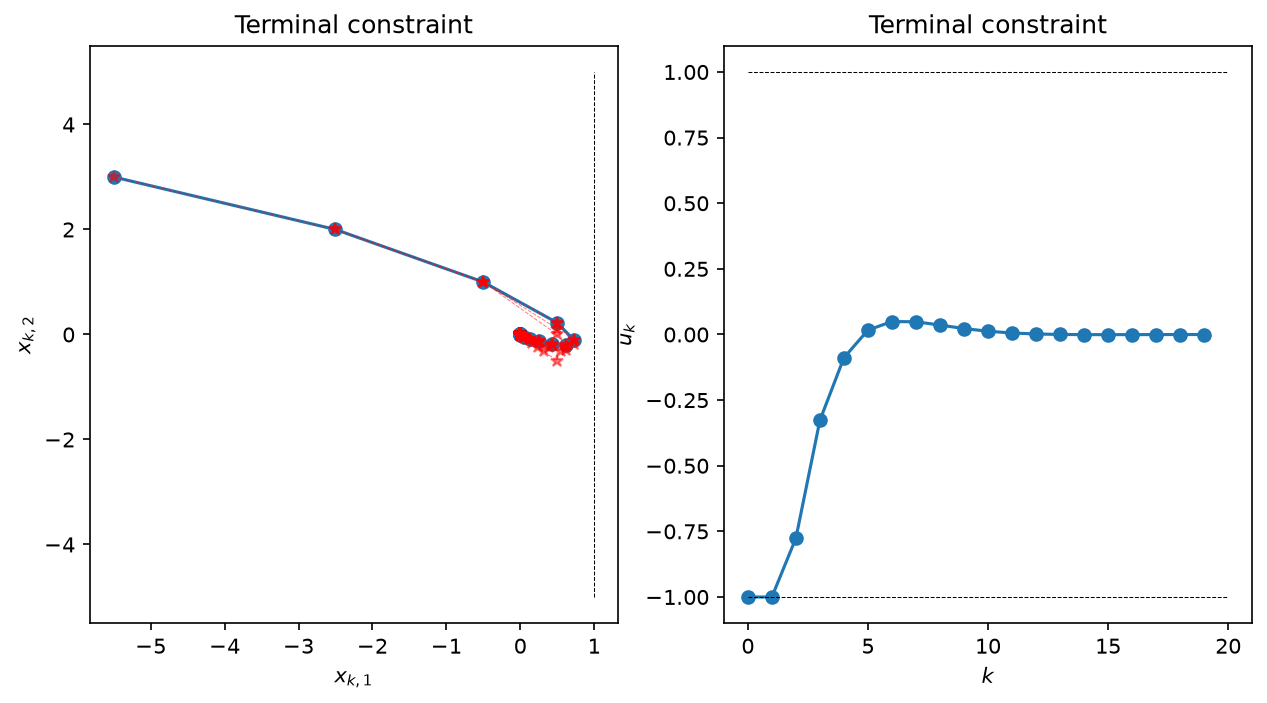

In [5]:
N = 5 # mpc horizon
T = 20 # simulation time
r_N = 0.0 # add terminal constraint
Q_f = solve_discrete_are(A, B, Q, R)

# Simulate the system
simulate(x0, T, N, x_upper, x_lower, r_u, Q_f, r_N, title="Terminal constraint")